In [1]:
# import key libraries and kernel settings
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [31]:
# from src.loading import load_data 


df_early_late_dual = pd.read_csv("../data/dual_generalization/early_late_2_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")
# filter so only -3.0 m/s
df_early_late_dual_3 = df_early_late_dual[df_early_late_dual['speed_label'] == -3.0]

# first 75 trials
df_early_late_single_3_f75 = pd.read_csv("../data/spatial_generalization/early_late_phase_2_PCA_error_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_neg3_0_first_75_training_1_2.csv")

# all
df_early_late_single_3_all = pd.read_csv("../data/spatial_generalization/early_late_phase_2_PCA_error_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_neg3_0.csv")

# combined
df_combined = pd.concat([df_early_late_dual_3, df_early_late_single_3_all])

# add new column to distinguish experiments
df_combined['single_target_training'] = df_combined['experiment'].str.contains('novel_TD_3.0M_spatial_generalization|novel_TU_3.0M_spatial_generalization').astype(int)
# add column to differ ppid by experiemnt
df_combined['new_ppid'] = df_combined['ppid_full'].astype(str) + "_" + df_combined['single_target_training'].astype(str)


In [27]:
df_combined

,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_trial_num,phase_target_trial_num,...,launch_deviation_mean,launch_deviation_median,flip_min_distance_xPCA_mean,flip_min_distance_xPCA_median,launch_deviation_mean_bc,launch_deviation_median_bc,flip_min_distance_xPCA_mean_bc,flip_min_distance_xPCA_median_bc,trial_set,PCA_extent_error_cm
0,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,53,training_1,1,1,...,0.153491,1.766991,-6.070105,-10.584746,2.752700,1.13920,67.908700,72.423341,early,NaN
1,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,55,training_1,3,2,...,0.153491,1.766991,-6.070105,-10.584746,68.679630,67.06613,18.885337,23.399978,early,NaN
2,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,199,training_1,147,74,...,0.153491,1.766991,-6.070105,-10.584746,75.419690,73.80619,-40.277301,-35.762660,late,NaN
3,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,201,training_1,149,75,...,0.153491,1.766991,-6.070105,-10.584746,76.259830,74.64633,-28.072542,-23.557901,late,NaN
4,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L30,-30.0,140.0,276,training_2,2,1,...,1.580477,1.759757,-8.042870,-9.686718,66.734850,66.55557,20.818379,22.462227,early,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,novel_TU_3.0M_spatial_generalization,p080_neg3,-3.0,L60,-60.0,140.0,311,training_2,2,2,...,0.027897,0.480659,-6.677197,-7.003292,-29.239597,-29.69236,19.366857,19.692951,early,-17.759640
284,novel_TU_3.0M_spatial_generalization,p080_neg3,-3.0,L60,-60.0,140.0,372,training_2,63,63,...,0.027897,0.480659,-6.677197,-7.003292,-76.145257,-76.59802,-4.368271,-4.042177,late,2.900691
285,novel_TU_3.0M_spatial_generalization,p080_neg3,-3.0,L60,-60.0,140.0,373,training_2,64,64,...,0.027897,0.480659,-6.677197,-7.003292,-73.814108,-74.26687,-5.249910,-4.923816,late,1.779664
286,novel_TU_3.0M_spatial_generalization,p080_neg3,-3.0,R60,60.0,140.0,276,training_1,224,224,...,0.549649,-0.113669,-1.028234,-3.487941,-11.823429,-11.16011,18.299499,20.759205,late,-19.423472


In [5]:
# combine df_early_late_single_3_f75 & df_early_late_dual_3
df_combined_f75 = pd.concat([df_early_late_dual_3, df_early_late_single_3_f75])

# add new column to distinguish experiments
df_combined_f75['single_target_training'] = df_combined_f75['experiment'].str.contains('novel_TD_3.0M_spatial_generalization|novel_TU_3.0M_spatial_generalization').astype(int)
# add column to differ ppid by experiemnt
df_combined_f75['new_ppid'] = df_combined_f75['ppid_full'].astype(str) + "_" + df_combined_f75['single_target_training'].astype(str)

# combine df_early_late_dual_3 & df_early_late_single_3_all
df_combined_all = pd.concat([df_early_late_dual_3, df_early_late_single_3_all])
df_combined_all['single_target_training'] = df_combined_f75['experiment'].str.contains('novel_TD_3.0M_spatial_generalization|novel_TU_3.0M_spatial_generalization').astype(int)
# add column to differ ppid by experiemnt
df_combined_all['new_ppid'] = df_combined_all['ppid_full'].astype(str) + "_" + df_combined_all['single_target_training'].astype(str)

print(df_combined_all.columns)

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_

TRIAL SET = LATE / LEARNING in First 75 T1 Trials:


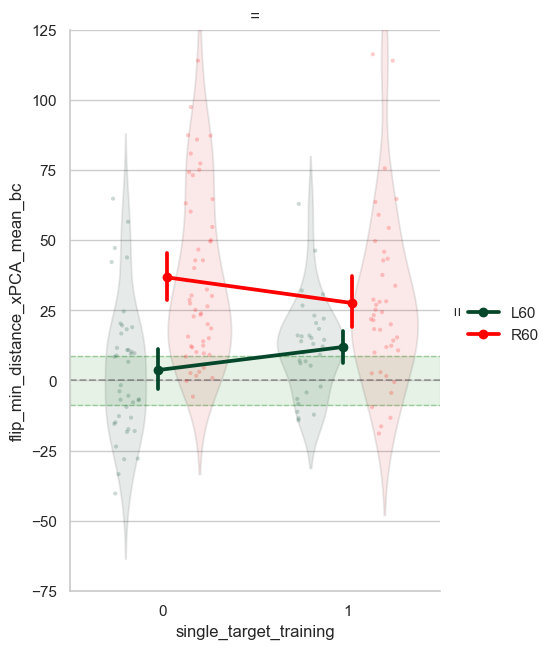

In [9]:
df_combined_f75_t1_late = df_combined_f75[
    (df_combined_f75['phase'] == "training_1") &
    (df_combined_f75['trial_set'] == 'late') &
    (df_combined_f75['target_x_label'].isin(['L60','R60']))
]

print("TRIAL SET = LATE / LEARNING in First 75 T1 Trials:")
from src.plotting import plot_slopes
plot_slopes(df_combined_f75_t1_late,
                         x_col='single_target_training',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row= None
                            )



TRIAL SET = LATE
LEARNING Single Target (0) = 75 trials in T1:
LEARNING Single Target (1) = 225 trials in T1:


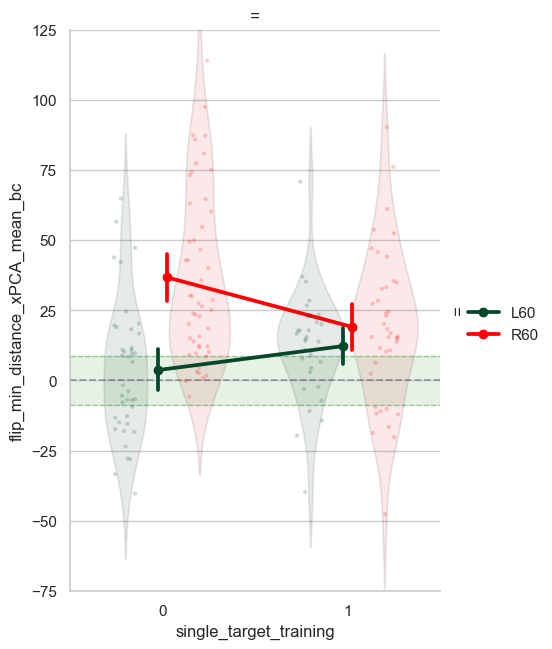

In [17]:
df_combined_all_t1_late = df_combined_all[
    (df_combined_all['phase'] == "training_1") &
    (df_combined_all['trial_set'] == 'late') &
    (df_combined_all['target_x_label'].isin(['L60','R60']))
]

print("TRIAL SET = LATE")
print("LEARNING Single Target (0) = 75 trials in T1:")
print("LEARNING Single Target (1) = 225 trials in T1:")
from src.plotting import plot_slopes
plot_slopes(df_combined_all_t1_late,
                         x_col='single_target_training',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row= None
                            )



transfer

first 75

EARLY PERFORMANCE / TAREGET ACROSS PHASES


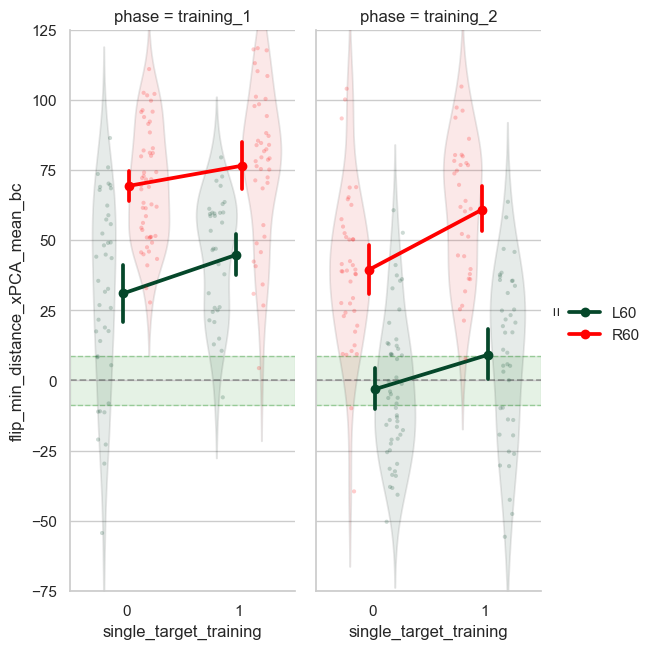

In [19]:
# filter out early t1 and late t2 trials
df_combined_t1_t2_early = df_combined_all[
    (df_combined_all['trial_set'] == 'early') &
    (df_combined_all['target_x_label'].isin(['L60', 'R60']))
]

print("EARLY PERFORMANCE / TAREGET ACROSS PHASES")

from src.plotting import plot_slopes
plot_slopes(df_combined_t1_t2_early,
                         x_col='single_target_training',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= None
                            )


TRIAL SET = LATE / LEARNING in First 75 T1 Trials:


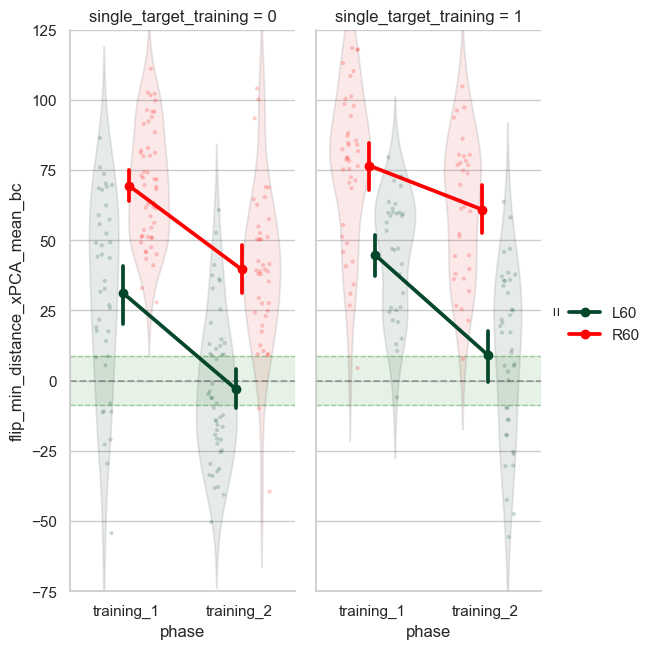

In [35]:
df_combined_early = df_combined[
    (df_combined['trial_set'] == 'early') &
    (df_combined['target_x_label'].isin(['L60','R60']))
]

print("TRIAL SET = LATE / LEARNING in First 75 T1 Trials:")
from src.plotting import plot_slopes
plot_slopes(df_combined_early,
                         x_col='phase',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='single_target_training',
                         facet_row= None
                            )

